# META — Variante Salida_LONG_SOLO_RSI

**Fecha y hora de modificación:** 2026-09-07 19:56:52 +0200 (Europe/Warsaw).

Esta variante simplifica la señal de salida del LONG a **RSI >= 65**, eliminando la salida por recuperación de la media de Bollinger de 20 sesiones. Se mantienen el stop LONG del 7 %, las reglas SHORT y Extras y el modelo de ejecución.

En la **prueba de los últimos 9 meses, del 04/12/2025 al 04/09/2026**, esta variante mejora el rendimiento de **META del +62,79 % al +87,9 %** (+87,94 % con dos decimales) al simplificar la salida del LONG a RSI >= 65. **No varía el rendimiento de NVDA (+11,56 %) ni de SHOP (+26,92 %)** en esa misma prueba.

El último LONG de META se valora mediante el cierre forzado de fin del periodo el 04/09/2026: no había una salida por RSI ejecutada dentro de esa ventana. Los resultados corresponden a esta prueba histórica; al ejecutar con fecha final automática pueden cambiar.

## Modelo de ejecución

- Las señales del cierre anterior se ejecutan en la apertura siguiente.
- Los gaps que atraviesan un stop se ejecutan en la apertura.
- Se aplica deslizamiento adverso en las compras y ventas.
- El stop queda activo desde la sesión de entrada.
- El trailing de SHORT EXTRA calculado al cierre se utiliza desde la sesión siguiente.

Se modelan órdenes stop-market con datos OHLC diarios, que no permiten reconstruir el recorrido intradía ni el precio exacto de ejecución.


In [1]:
# ========================= CONFIGURACIÓN =========================
# Cada elemento contiene el ticker de Yahoo Finance y su capital inicial.
# Descomenta o añade valores para analizarlos. Se admite cualquier cantidad
# razonable, aunque los gráficos serán más legibles con pocos activos.
ACTIVOS = [
    ('META', 10_000),
    #('AAPL', 10_000),
    #('MSFT', 10_000),
    ('NVDA', 10_000),
    #('AMZN', 10_000),
    ('SHOP', 10_000),
    # ('ASML.AS', 10_000),
    # ('ITX.MC', 10_000),
]

# Puede indicarse una sola ventana, por ejemplo [9], o varias.
VENTANAS_MESES = [9]

# None o 'HOY': termina en la última sesión disponible hasta hoy.
# También puede fijarse una fecha histórica con formato AAAA-MM-DD.
FECHA_FIN_VENTANA = None
# FECHA_FIN_VENTANA = '2026-08-21'

# Parámetros heredados literalmente del cuaderno Con_Extras.
STOP_LONG = 0.07
STOP_SHORT = 0.07
DESLIZAMIENTO_BPS = 5  # 5 puntos básicos adversos en cada ejecución.
PERIODO_RUPTURA = 20
MULTIPLICADOR_VOLUMEN = 1.00

# Parámetros exclusivos del módulo EXTRA.
EXTRA_RUPTURA = 10
EXTRA_REBOTE_LOOKBACK = 5
EXTRA_STOP = 0.05
EXTRA_ATR = 2.0
EXTRA_MAX_DIAS = 15

# True muestra un gráfico por activo y ventana con las operaciones de Extras.
MOSTRAR_GRAFICOS = True
# =================================================================


In [2]:
# ================= IMPORTACIÓN Y DESCARGA DE DATOS =================
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from dateutil.relativedelta import relativedelta
from IPython import get_ipython
from IPython.display import display

warnings.filterwarnings('ignore')
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic('matplotlib', 'inline')
pd.set_option('display.max_columns', None)

# Validaciones tempranas para detectar errores de configuración claramente.
if not ACTIVOS:
    raise ValueError('ACTIVOS debe contener al menos un ticker.')
tickers = [str(t).strip().upper() for t, _ in ACTIVOS]
capitales = {str(t).strip().upper(): float(c) for t, c in ACTIVOS}
if len(tickers) != len(set(tickers)):
    raise ValueError('No puede haber tickers duplicados en ACTIVOS.')
if any(c <= 0 for c in capitales.values()):
    raise ValueError('Todos los capitales iniciales deben ser positivos.')
if not VENTANAS_MESES or any(not isinstance(m, int) or m <= 0 for m in VENTANAS_MESES):
    raise ValueError('VENTANAS_MESES debe contener enteros positivos.')
VENTANAS_MESES = sorted(set(VENTANAS_MESES))

# Resuelve la fecha solicitada. yfinance interpreta `end` como límite exclusivo,
# por eso posteriormente se añade un día para poder incluir la fecha final.
hoy = pd.Timestamp.today().normalize()
if FECHA_FIN_VENTANA is None or str(FECHA_FIN_VENTANA).strip().upper() == 'HOY':
    fecha_fin_solicitada = hoy
else:
    fecha_fin_solicitada = pd.Timestamp(FECHA_FIN_VENTANA).normalize()
if fecha_fin_solicitada > hoy:
    raise ValueError('FECHA_FIN_VENTANA no puede ser posterior a hoy.')

# Se conservan como mínimo los cinco años descargados por el notebook original.
# Si se pide una ventana mayor, se amplía además cinco meses para calentar RSI,
# medias, Bollinger y ATR. Los precios siguen SIN ajustar (auto_adjust=False).
meses_descarga = max(60, max(VENTANAS_MESES) + 5)
inicio_descarga = fecha_fin_solicitada - relativedelta(months=meses_descarga)
datos_raw, errores = {}, []
for ticker in tickers:
    try:
        d = yf.download(
            ticker,
            start=inicio_descarga,
            end=fecha_fin_solicitada + pd.Timedelta(days=1),
            interval='1d',
            auto_adjust=False,
            progress=False
        )
        if d.empty:
            raise RuntimeError('descarga vacía')
        if isinstance(d.columns, pd.MultiIndex):
            d.columns = d.columns.get_level_values(0)
        d = d[['Open', 'High', 'Low', 'Close', 'Volume']].dropna().copy()
        d.index = pd.DatetimeIndex(d.index).tz_localize(None).normalize()
        d = d[~d.index.duplicated(keep='last')].sort_index()
        datos_raw[ticker] = d
    except Exception as exc:
        errores.append(f'{ticker}: {exc}')

if errores:
    raise RuntimeError('No se pudieron preparar todos los activos:\n' + '\n'.join(errores))

# Para comparar mercados con calendarios festivos distintos se busca la última
# fecha que exista realmente en todos los activos, no solo la menor fecha máxima.
sesiones_comunes = set.intersection(*(set(d.index) for d in datos_raw.values()))
if not sesiones_comunes:
    raise RuntimeError('Los activos seleccionados no tienen ninguna sesión común.')
ultima_fecha_comun = max(sesiones_comunes)
print('Valores:', ', '.join(tickers))
print('Ventanas:', ', '.join(f'{m} meses' for m in VENTANAS_MESES))
print('Fecha final solicitada:', fecha_fin_solicitada.date())
print('Última sesión común utilizada:', ultima_fecha_comun.date())


Valores: META, NVDA, SHOP
Ventanas: 9 meses
Fecha final solicitada: 2026-09-07
Última sesión común utilizada: 2026-09-04


In [3]:
# ======================= SEÑALES ORIGINALES =======================
def preparar_senales(df):
    """Calcula las señales de Con_Extras con salida LONG solo por RSI >= 65."""
    d = df.copy()
    delta = d['Close'].diff()
    subida, bajada = delta.clip(lower=0), -delta.clip(upper=0)
    rs = subida.rolling(14).mean() / bajada.rolling(14).mean()
    d['RSI'] = 100 - 100 / (1 + rs)
    d['BB_MIDDLE'] = d['Close'].rolling(20).mean()
    desv = d['Close'].rolling(20).std()
    d['BB_LOWER'] = d['BB_MIDDLE'] - 2 * desv
    d['EMA10'] = d['Close'].ewm(span=10, adjust=False).mean()
    d['SMA20'] = d['Close'].rolling(20).mean()
    d['SMA50'] = d['Close'].rolling(50).mean()
    previo = d['Close'].shift(1)
    tr = pd.concat([
        d['High'] - d['Low'],
        (d['High'] - previo).abs(),
        (d['Low'] - previo).abs()
    ], axis=1).max(axis=1)
    d['ATR14'] = tr.ewm(alpha=1 / 14, adjust=False).mean()

    # Reglas originales salvo la salida LONG: solo RSI >= 65.
    d['LONG_ENTRY'] = (d['RSI'] < 30) & (d['Close'] <= d['BB_LOWER'])
    d['LONG_EXIT'] = d['RSI'] >= 65
    d['MINIMO_20_PREV'] = d['Low'].rolling(PERIODO_RUPTURA).min().shift(1)
    d['VOL_20_PREV'] = d['Volume'].rolling(PERIODO_RUPTURA).mean().shift(1)
    d['SHORT_RSI'] = d['RSI'] > 70
    d['SHORT_RUPTURA'] = (
        (d['Close'] < d['MINIMO_20_PREV'])
        & (d['Volume'] > d['VOL_20_PREV'] * MULTIPLICADOR_VOLUMEN)
    )
    d['SHORT_ENTRY'] = d['SHORT_RSI'] | d['SHORT_RUPTURA']
    d['SHORT_EXIT'] = d['RSI'] < 50

    # Candidato EXTRA: rebote reciente y ruptura rápida en tendencia bajista.
    d['MINIMO_EXTRA_PREV'] = d['Low'].rolling(EXTRA_RUPTURA).min().shift(1)
    d['REBOTE_RECIENTE'] = (
        (d['Close'] > d['EMA10'])
        .rolling(EXTRA_REBOTE_LOOKBACK).max().shift(1)
        .fillna(False).astype(bool)
    )
    d['SHORT_EXTRA'] = (
        (d['Close'] < d['MINIMO_EXTRA_PREV'])
        & d['REBOTE_RECIENTE']
        & (d['Close'] < d['SMA50'])
        & (d['SMA20'] < d['SMA50'])
        & (d['Volume'] > d['VOL_20_PREV'])
        & (~d['SHORT_ENTRY'])
    )
    return d


# Los indicadores se calculan antes de recortar cada ventana, de modo idéntico
# al original, para disponer del historial previo necesario para calentarlos.
datos = {
    ticker: preparar_senales(d.loc[d.index <= ultima_fecha_comun])
    for ticker, d in datos_raw.items()
}


In [4]:
# ============== MOTOR CORREGIDO CONTRA SESGO OPTIMISTA ==============
def ejecutar_backtest(df, capital_inicial):
    """Simula las reglas originales con una secuencia de ejecución conservadora.

    Las señales del cierre anterior se ejecutan en la apertura siguiente. Los
    stops ya activos distinguen entre gaps y cruces intradía, y toda ejecución
    incorpora un deslizamiento adverso configurable.
    """
    d = df.copy()
    capital = float(capital_inicial)
    posicion = precio_entrada = fecha_entrada = sistema = None
    operaciones, equity = [], []
    minimo_extra, trailing_extra, dias_extra = np.inf, np.inf, 0
    deslizamiento = DESLIZAMIENTO_BPS / 10_000

    def precio_con_deslizamiento(precio, lado):
        """Empeora el precio teórico: compras más caras y ventas más baratas."""
        factor = 1 + deslizamiento if lado == 'COMPRA' else 1 - deslizamiento
        return float(precio) * factor

    def abrir(tipo, sist, fecha, precio_referencia):
        nonlocal posicion, sistema, fecha_entrada, precio_entrada
        nonlocal minimo_extra, trailing_extra, dias_extra
        lado = 'COMPRA' if tipo == 'LONG' else 'VENTA'
        precio = precio_con_deslizamiento(precio_referencia, lado)
        posicion, sistema, fecha_entrada, precio_entrada = tipo, sist, fecha, precio
        minimo_extra, trailing_extra, dias_extra = precio, precio * (1 + EXTRA_STOP), 0

    def cerrar(fecha, precio_referencia, motivo):
        nonlocal capital, posicion, sistema, fecha_entrada, precio_entrada
        lado = 'VENTA' if posicion == 'LONG' else 'COMPRA'
        precio = precio_con_deslizamiento(precio_referencia, lado)
        retorno = (
            (precio - precio_entrada) / precio_entrada
            if posicion == 'LONG'
            else (precio_entrada - precio) / precio_entrada
        )
        capital *= 1 + retorno
        operaciones.append({
            'Tipo': posicion.replace('_BASE', '').replace('_EXTRA', ''),
            'Sistema entrada': sistema,
            'Entrada': fecha_entrada,
            'Precio entrada': precio_entrada,
            'Salida': fecha,
            'Precio salida': precio,
            'Rentabilidad %': retorno * 100,
            'Motivo': motivo,
            'Es original': sistema != 'EXTRA CONTINUACIÓN'
        })
        posicion = sistema = fecha_entrada = precio_entrada = None

    for i in range(1, len(d)):
        fecha, fila, senal = d.index[i], d.iloc[i], d.iloc[i - 1]
        apertura, maximo, minimo, cierre = map(
            float, [fila['Open'], fila['High'], fila['Low'], fila['Close']]
        )
        posicion_al_abrir = posicion
        long_original = bool(senal['LONG_ENTRY'])
        short_original = bool(senal['SHORT_ENTRY'])
        abierta_hoy = False

        # Una posición EXTRA contabiliza la nueva sesión antes de evaluar las
        # salidas que ya son conocidas al llegar a esta apertura.
        if posicion_al_abrir == 'SHORT_EXTRA':
            dias_extra += 1

        # 1) ÓRDENES CONOCIDAS EN LA APERTURA. Se procesan antes de consultar
        # High/Low, porque esos extremos todavía no existían al abrir el mercado.
        if posicion == 'SHORT_EXTRA' and (long_original or short_original):
            cerrar(fecha, apertura, 'PRIORIDAD A SEÑAL ORIGINAL')
            if long_original:
                abrir('LONG', 'RSI + BOLLINGER', fecha, apertura)
            else:
                sist = 'RUPTURA' if bool(senal['SHORT_RUPTURA']) else 'RSI > 70'
                abrir('SHORT_BASE', sist, fecha, apertura)
            abierta_hoy = True

        elif posicion == 'LONG' and bool(senal['LONG_EXIT']):
            cerrar(fecha, apertura, 'SEÑAL SALIDA LONG')

        elif posicion == 'SHORT_BASE' and bool(senal['SHORT_EXIT']):
            cerrar(fecha, apertura, 'SEÑAL SALIDA SHORT')

        elif posicion == 'SHORT_EXTRA':
            dos_cierres_sobre_ema = i >= 2 and bool(
                (d['Close'].iloc[i - 2:i] > d['EMA10'].iloc[i - 2:i]).all()
            )
            if bool(senal['RSI'] < 35):
                cerrar(fecha, apertura, 'OBJETIVO RSI EXTRA')
            elif dos_cierres_sobre_ema:
                cerrar(fecha, apertura, 'RECUPERA EMA10')
            elif dias_extra >= EXTRA_MAX_DIAS:
                cerrar(fecha, apertura, 'TIEMPO MÁXIMO EXTRA')

        # 2) STOPS QUE YA ESTABAN ACTIVOS ANTES DE LA APERTURA. Si el mercado
        # abre más allá del stop, una orden stop-market se aproxima con el Open.
        if posicion is not None and posicion_al_abrir is not None and not abierta_hoy:
            if posicion == 'LONG':
                stop = precio_entrada * (1 - STOP_LONG)
                if apertura <= stop:
                    cerrar(fecha, apertura, 'STOP LOSS LONG - GAP')
                elif minimo <= stop:
                    cerrar(fecha, stop, 'STOP LOSS LONG')

            elif posicion == 'SHORT_BASE':
                stop = precio_entrada * (1 + STOP_SHORT)
                if apertura >= stop:
                    cerrar(fecha, apertura, 'STOP LOSS SHORT - GAP')
                elif maximo >= stop:
                    cerrar(fecha, stop, 'STOP LOSS SHORT')

            elif posicion == 'SHORT_EXTRA':
                stop = min(precio_entrada * (1 + EXTRA_STOP), trailing_extra)
                if apertura >= stop:
                    cerrar(fecha, apertura, 'STOP/TRAILING EXTRA - GAP')
                elif maximo >= stop:
                    cerrar(fecha, stop, 'STOP/TRAILING EXTRA')

        # 3) ENTRADAS. Se conserva la regla original de no reabrir una posición
        # normal el mismo día que otra estaba abierta. La sustitución explícita
        # de un EXTRA por una señal original ya se ha tratado en el bloque 1.
        if posicion is None and posicion_al_abrir is None:
            if long_original:
                abrir('LONG', 'RSI + BOLLINGER', fecha, apertura)
                abierta_hoy = True
            elif short_original:
                sist = 'RUPTURA' if bool(senal['SHORT_RUPTURA']) else 'RSI > 70'
                abrir('SHORT_BASE', sist, fecha, apertura)
                abierta_hoy = True
            elif bool(senal['SHORT_EXTRA']):
                abrir('SHORT_EXTRA', 'EXTRA CONTINUACIÓN', fecha, apertura)
                abierta_hoy = True

        # 4) El stop queda activo inmediatamente después de entrar. Al derivarse
        # de la propia apertura no existe gap de entrada, pero sí puede tocarse
        # durante esa primera sesión.
        if posicion is not None and abierta_hoy:
            if posicion == 'LONG':
                stop = precio_entrada * (1 - STOP_LONG)
                if minimo <= stop:
                    cerrar(fecha, stop, 'STOP MISMA SESIÓN DE ENTRADA LONG')
            elif posicion == 'SHORT_BASE':
                stop = precio_entrada * (1 + STOP_SHORT)
                if maximo >= stop:
                    cerrar(fecha, stop, 'STOP MISMA SESIÓN DE ENTRADA SHORT')
            elif posicion == 'SHORT_EXTRA':
                stop = precio_entrada * (1 + EXTRA_STOP)
                if maximo >= stop:
                    cerrar(fecha, stop, 'STOP MISMA SESIÓN DE ENTRADA EXTRA')

        # 5) ACTUALIZACIÓN AL CIERRE. Este trailing no participa en la sesión
        # que acaba de terminar; solamente estará activo en la siguiente.
        if posicion == 'SHORT_EXTRA':
            minimo_extra = min(minimo_extra, cierre)
            if pd.notna(fila['ATR14']):
                candidato = minimo_extra + EXTRA_ATR * float(fila['ATR14'])
                trailing_extra = min(trailing_extra, candidato)

        if posicion == 'LONG':
            valor = capital * (1 + (cierre - precio_entrada) / precio_entrada)
        elif posicion in ('SHORT_BASE', 'SHORT_EXTRA'):
            valor = capital * (1 + (precio_entrada - cierre) / precio_entrada)
        else:
            valor = capital
        equity.append({'Fecha': fecha, 'Equity': valor})

    if posicion is not None:
        cerrar(d.index[-1], float(d['Close'].iloc[-1]), 'FIN DEL PERIODO')
        equity[-1]['Equity'] = capital

    eq = pd.DataFrame(equity).set_index('Fecha')
    dd = ((eq['Equity'] / eq['Equity'].cummax()) - 1).min() * 100
    aciertos = (
        100 * sum(o['Rentabilidad %'] > 0 for o in operaciones) / len(operaciones)
        if operaciones else 0
    )
    return {
        'Capital inicial': capital_inicial,
        'Capital final': capital,
        'Rentabilidad %': (capital / capital_inicial - 1) * 100,
        'Drawdown máximo %': dd,
        'Operaciones': operaciones,
        '% Aciertos': aciertos,
        'Equity': eq,
        'Fecha inicio': d.index[0],
        'Fecha fin': d.index[-1]
    }


In [5]:
# ======================= EJECUCIÓN Y RESULTADOS =======================
resultados, filas = {}, []
for meses in VENTANAS_MESES:
    resultados[meses] = {}
    fecha_objetivo = ultima_fecha_comun - relativedelta(months=meses)

    for ticker in tickers:
        # Primera sesión real disponible dentro de los límites solicitados.
        periodo = datos[ticker].loc[
            (datos[ticker].index >= fecha_objetivo)
            & (datos[ticker].index <= ultima_fecha_comun)
        ].copy()
        if len(periodo) < 2:
            raise ValueError(f'{ticker}: datos insuficientes para {meses} meses.')

        resultado = ejecutar_backtest(periodo, capitales[ticker])

        resultados[meses][ticker] = {
            'datos': periodo,
            'Resultado': resultado
        }

        # Buy & Hold compra en la primera apertura de la ventana y valora
        # la posición al último cierre, usando exactamente el mismo periodo.
        rentabilidad_buy_hold = (
            float(periodo['Close'].iloc[-1]) / float(periodo['Open'].iloc[0]) - 1
        ) * 100
        filas.append({
                'Ventana': meses,
                'Ticker': ticker,
                'Fecha inicio': resultado['Fecha inicio'],
                'Fecha fin': resultado['Fecha fin'],
                'Capital inicial': resultado['Capital inicial'],
                'Capital final': resultado['Capital final'],
                'Rentabilidad %': resultado['Rentabilidad %'],
                'Buy & Hold %': rentabilidad_buy_hold,
                'Drawdown máximo %': resultado['Drawdown máximo %'],
                'Operaciones': len(resultado['Operaciones']),
                '% Aciertos': resultado['% Aciertos']
        })

tabla = pd.DataFrame(filas)
print('RESULTADOS')
display(tabla.style.format({
    'Fecha inicio': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Fecha fin': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
    'Capital inicial': '${:,.2f}',
    'Capital final': '${:,.2f}',
    'Rentabilidad %': '{:+.2f}%',
    'Buy & Hold %': '{:+.2f}%',
    'Drawdown máximo %': '{:+.2f}%',
    '% Aciertos': '{:.1f}%'
}))



RESULTADOS


,Ventana,Ticker,Fecha inicio,Fecha fin,Capital inicial,Capital final,Rentabilidad %,Buy & Hold %,Drawdown máximo %,Operaciones,% Aciertos
0,9,META,2025-12-04,2026-09-04,"$10,000.00","$18,794.33",+87.94%,-8.76%,-10.84%,11,72.7%
1,9,NVDA,2025-12-04,2026-09-04,"$10,000.00","$11,156.36",+11.56%,+26.84%,-11.17%,13,53.8%
2,9,SHOP,2025-12-04,2026-09-04,"$10,000.00","$12,692.27",+26.92%,-9.51%,-13.02%,13,69.2%


OPERACIONES — ESTRATEGIA CON EXTRAS


,Ventana,Ticker,Operación,Tipo,Sistema entrada,Entrada,Precio entrada,Salida,Precio salida,Rentabilidad %,Motivo,Es original
0,9 meses,META,1,SHORT,RSI > 70,2025-12-05,$663.67,2025-12-12,$710.48,-7.05%,STOP LOSS SHORT,True
1,9 meses,META,2,SHORT,RUPTURA,2026-01-14,$626.19,2026-01-15,$618.79,+1.18%,SEÑAL SALIDA SHORT,True
2,9 meses,META,3,LONG,RSI + BOLLINGER,2026-01-16,$624.49,2026-01-30,$727.14,+16.44%,SEÑAL SALIDA LONG,True
3,9 meses,META,4,SHORT,RUPTURA,2026-03-16,$631.68,2026-03-17,$628.30,+0.54%,SEÑAL SALIDA SHORT,True
4,9 meses,META,5,SHORT,RUPTURA,2026-03-20,$603.23,2026-03-23,$606.09,-0.47%,SEÑAL SALIDA SHORT,True
5,9 meses,META,6,LONG,RSI + BOLLINGER,2026-03-27,$540.37,2026-04-15,$666.67,+23.37%,SEÑAL SALIDA LONG,True
6,9 meses,META,7,SHORT,RSI > 70,2026-04-17,$678.26,2026-05-01,$615.00,+9.33%,SEÑAL SALIDA SHORT,True
7,9 meses,META,8,SHORT,EXTRA CONTINUACIÓN,2026-06-08,$591.70,2026-06-12,$573.24,+3.12%,PRIORIDAD A SEÑAL ORIGINAL,False
8,9 meses,META,9,SHORT,RUPTURA,2026-06-12,$572.66,2026-06-15,$580.19,-1.31%,SEÑAL SALIDA SHORT,True
9,9 meses,META,10,SHORT,RSI > 70,2026-07-16,$676.94,2026-07-27,$607.52,+10.25%,SEÑAL SALIDA SHORT,True


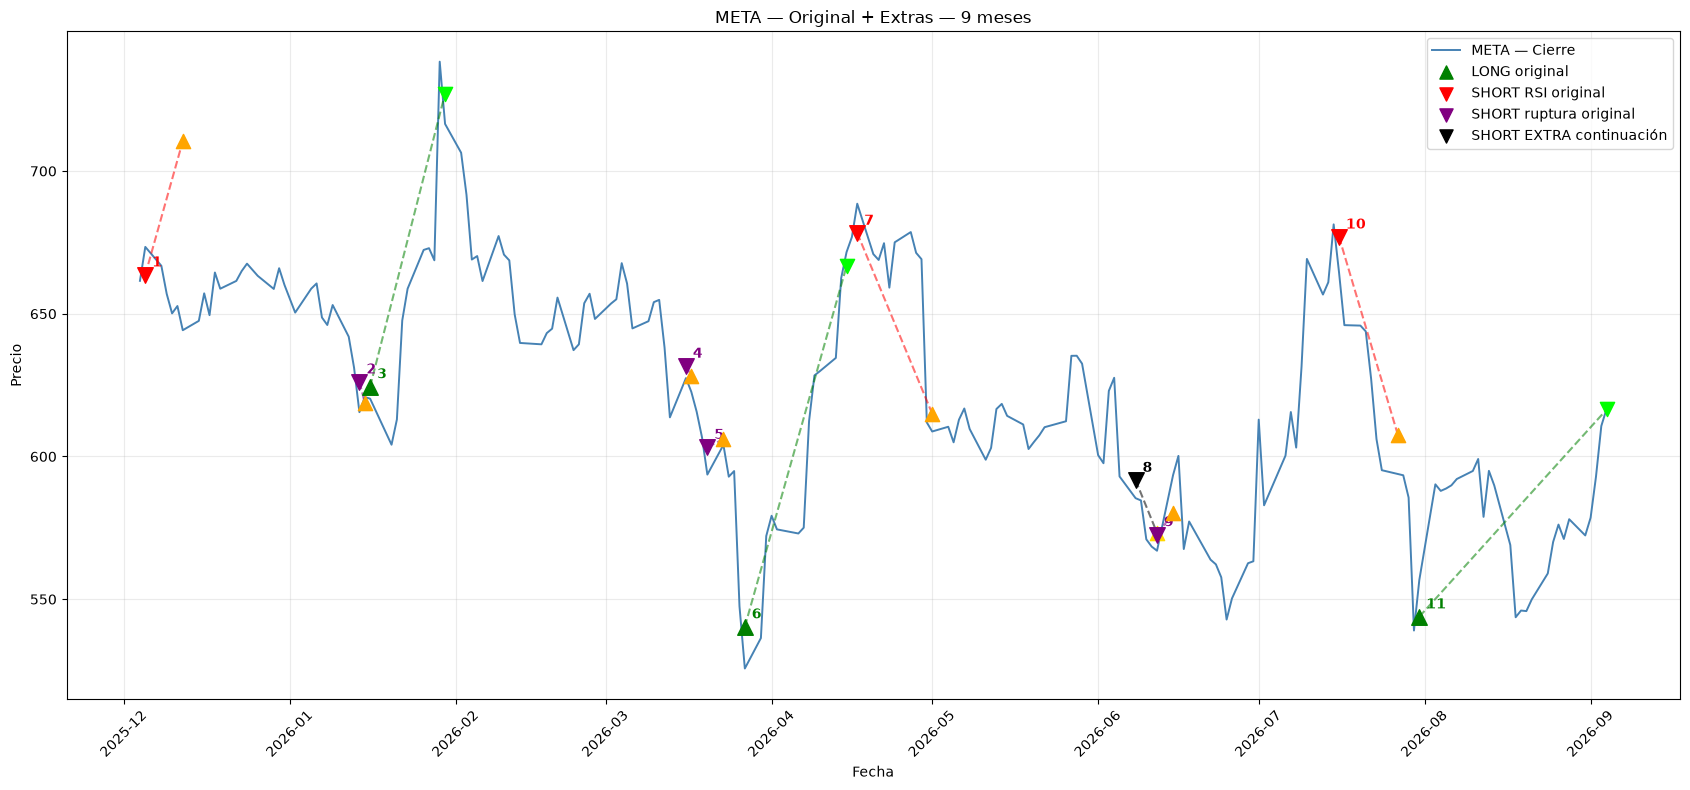

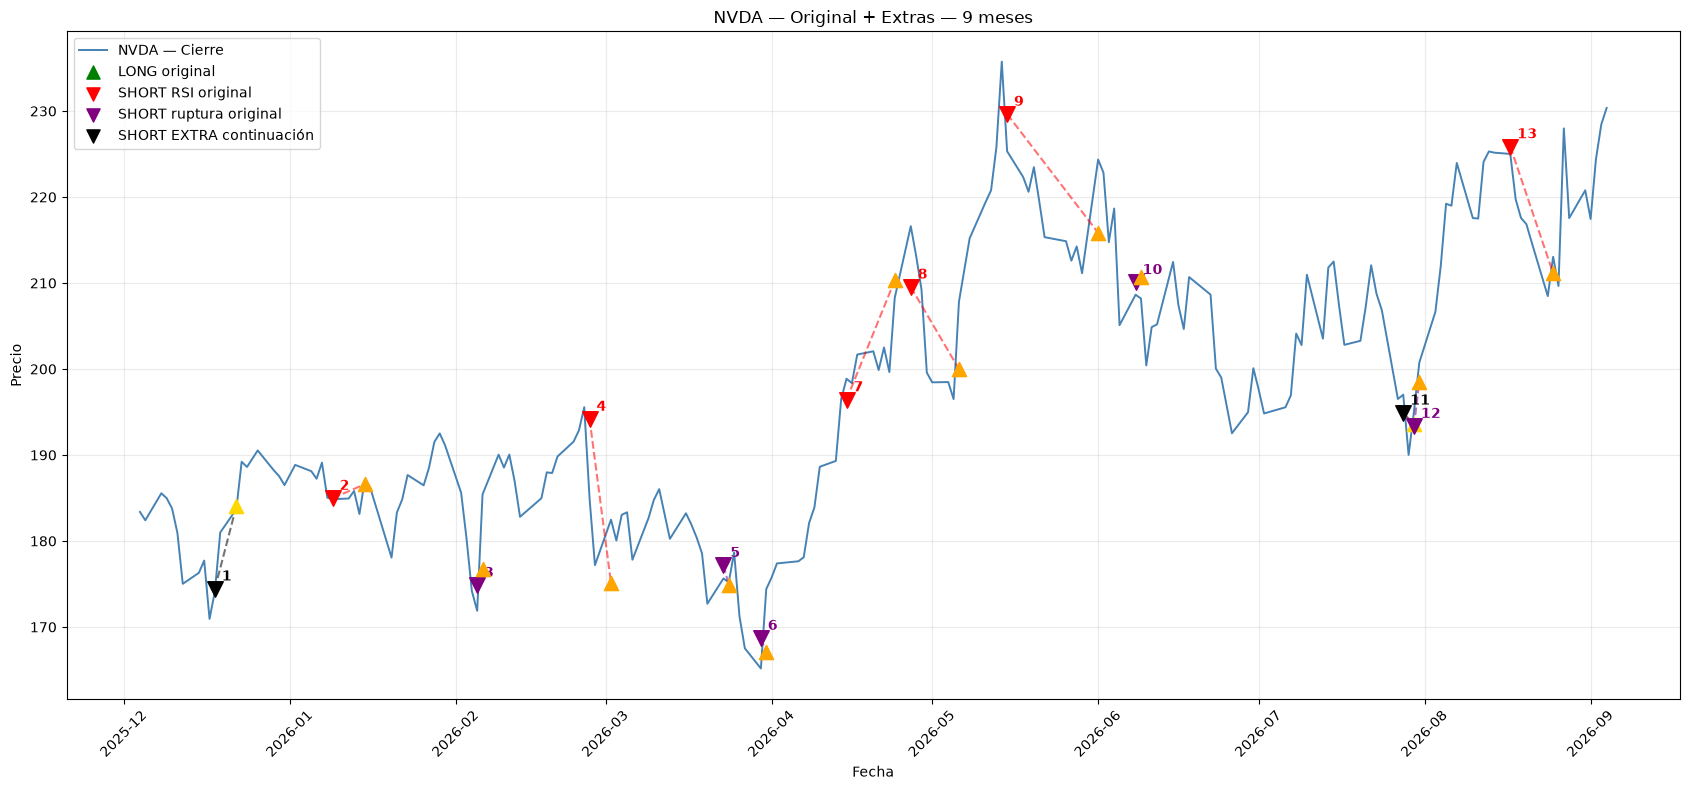

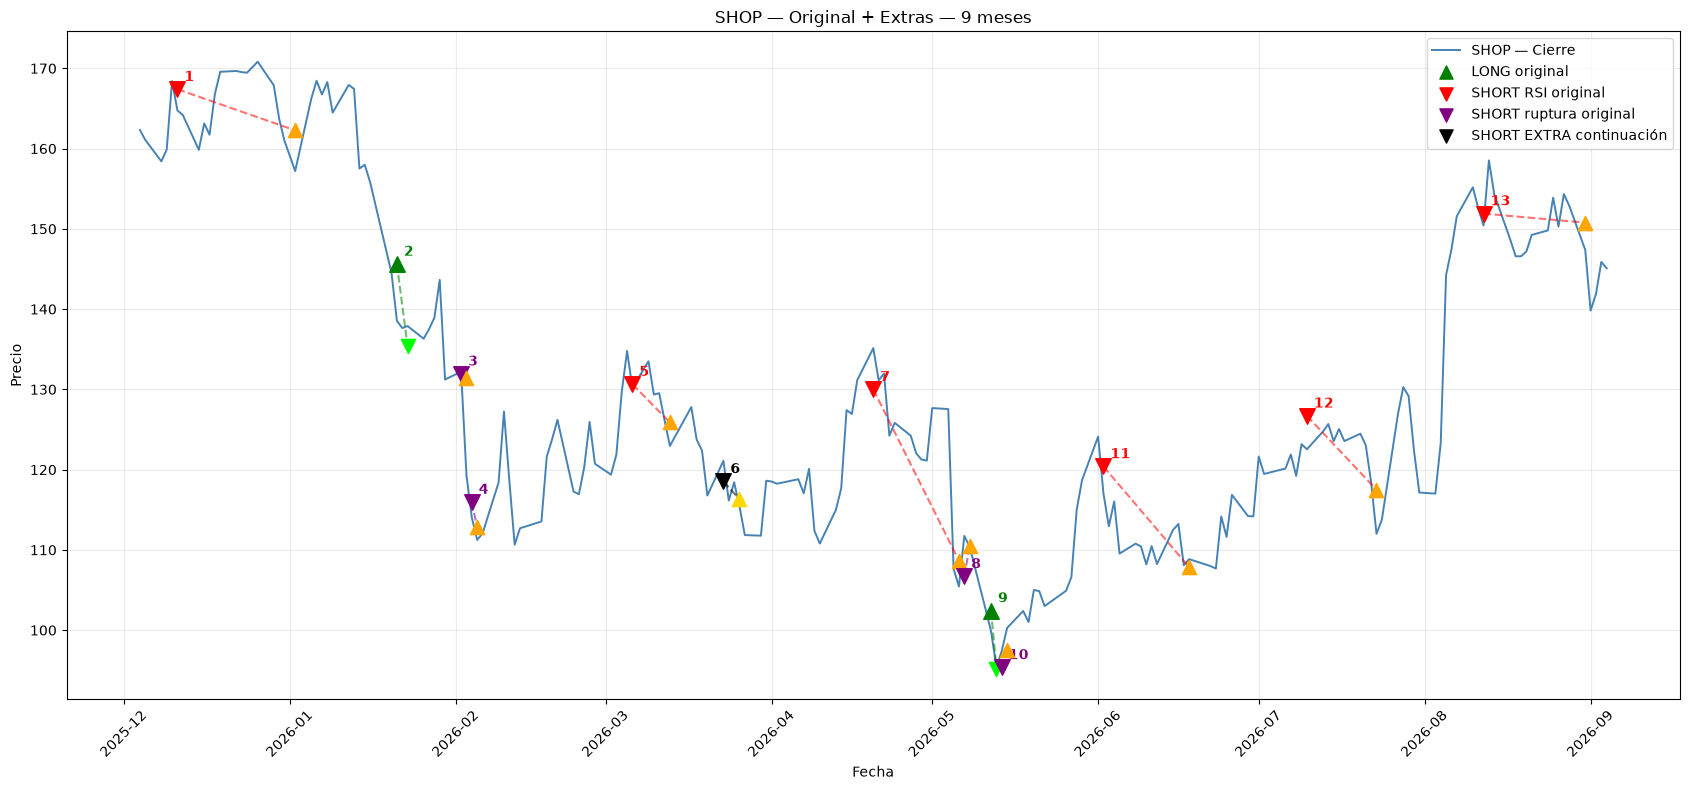

In [6]:
# ================= DETALLE DE OPERACIONES Y GRÁFICOS =================
detalle = []
for meses in VENTANAS_MESES:
    for ticker in tickers:
        pack = resultados[meses][ticker]['Resultado']
        for numero, op in enumerate(pack['Operaciones'], start=1):
            detalle.append({
                'Ventana': f'{meses} meses',
                'Ticker': ticker,
                'Operación': numero,
                **op
            })

print('OPERACIONES — ESTRATEGIA CON EXTRAS')
if detalle:
    display(pd.DataFrame(detalle).style.format({
        'Entrada': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
        'Salida': lambda x: pd.Timestamp(x).strftime('%Y-%m-%d'),
        'Precio entrada': '${:,.2f}',
        'Precio salida': '${:,.2f}',
        'Rentabilidad %': '{:+.2f}%'
    }))
else:
    print('No se generaron operaciones.')

if MOSTRAR_GRAFICOS:
    for meses in VENTANAS_MESES:
        for ticker in tickers:
            bloque = resultados[meses][ticker]
            periodo = bloque['datos']
            pack = bloque['Resultado']
            fig, ax = plt.subplots(figsize=(17, 8))
            ax.plot(periodo.index, periodo['Close'], lw=1.4, color='steelblue', label=f'{ticker} — Cierre')

            for numero, op in enumerate(pack['Operaciones'], start=1):
                extra = not op['Es original']
                if extra:
                    color, marker = 'black', 'v'
                elif op['Tipo'] == 'LONG':
                    color, marker = 'green', '^'
                elif op['Sistema entrada'] == 'RUPTURA':
                    color, marker = 'purple', 'v'
                else:
                    color, marker = 'red', 'v'
                ax.scatter(op['Entrada'], op['Precio entrada'], color=color, marker=marker, s=125, zorder=6)
                ax.scatter(
                    op['Salida'], op['Precio salida'],
                    color='gold' if extra else ('lime' if op['Tipo'] == 'LONG' else 'orange'),
                    marker='^' if op['Tipo'] == 'SHORT' else 'v', s=105, zorder=6
                )
                ax.plot(
                    [op['Entrada'], op['Salida']],
                    [op['Precio entrada'], op['Precio salida']],
                    color=color, ls='--', alpha=.55
                )
                ax.annotate(
                    str(numero), (op['Entrada'], op['Precio entrada']),
                    xytext=(5, 6), textcoords='offset points', color=color, weight='bold'
                )

            ax.scatter([], [], color='green', marker='^', s=90, label='LONG original')
            ax.scatter([], [], color='red', marker='v', s=90, label='SHORT RSI original')
            ax.scatter([], [], color='purple', marker='v', s=90, label='SHORT ruptura original')
            ax.scatter([], [], color='black', marker='v', s=90, label='SHORT EXTRA continuación')
            ax.set_title(f'{ticker} — Original + Extras — {meses} meses')
            ax.set_xlabel('Fecha')
            ax.set_ylabel('Precio')
            ax.grid(alpha=.25)
            ax.legend(loc='best')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()


## Interpretación

- Cada activo reinvierte exclusivamente su propio capital inicial.
- Las ventanas son independientes y terminan en la última sesión común disponible hasta `FECHA_FIN_VENTANA`.
- Los indicadores disponen de cinco meses previos de calentamiento, pero el capital y las operaciones empiezan dentro de la ventana elegida.
- La estrategia con Extras está siempre activa; este notebook no ejecuta ni muestra una variante separada sin Extras.
- Se aplica `DESLIZAMIENTO_BPS` en cada compra y venta y los gaps contra stops se ejecutan aproximadamente en la apertura.
- No se incluyen comisiones, impuestos, intereses, costes de préstamo de posiciones cortas ni el spread real de cada sesión.
- Con OHLC diario no puede conocerse el recorrido intradía ni el precio real exacto de una orden stop-market.
- Los resultados históricos no garantizan rendimientos futuros.
